<a href="https://colab.research.google.com/github/divya374r1/Neural-Network-and-Deep-Learning/blob/main/Student_attendance_system(E5).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()


Saving image 2.jpeg to image 2.jpeg
Saving image 1.jpeg to image 1.jpeg


Files renamed successfully!
Student faces loaded successfully!
Look at the camera... Capturing image in 3 seconds


<IPython.core.display.Javascript object>

🟢 Student Present: student2


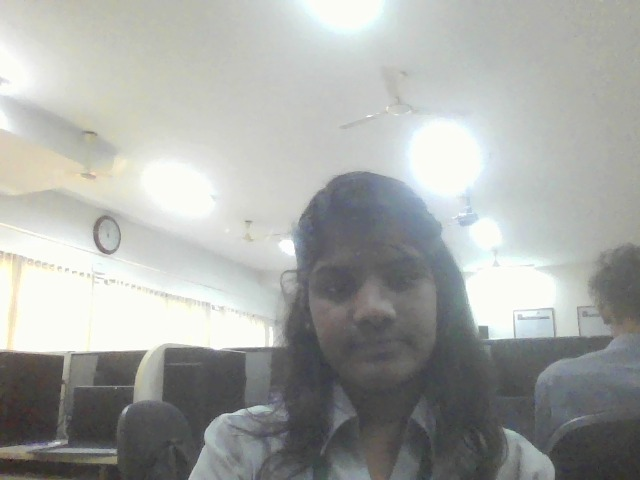

In [11]:
# ==========================================
# EXPERIMENT 5 - STUDENT ATTENDANCE SYSTEM
# Face Recognition (Fixed for your filenames)
# ==========================================

# Install required libraries
!pip install -q face_recognition
!apt-get install -y -qq cmake
!pip install -q opencv-python

import face_recognition
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from google.colab import output
from IPython.display import Javascript, display
from base64 import b64decode
import os

# -----------------------------------
# STEP 1: Rename files (remove spaces)
# -----------------------------------

if os.path.exists("image 1.jpeg"):
    os.rename("image 1.jpeg", "student1.jpeg")

if os.path.exists("image 2.jpeg"):
    os.rename("image 2.jpeg", "student2.jpeg")

print("Files renamed successfully!")

# -----------------------------------
# STEP 2: Load Known Student Images
# -----------------------------------

known_face_encodings = []
known_face_names = []

student_images = ["student1.jpeg", "student2.jpeg"]

for img_path in student_images:
    image = face_recognition.load_image_file(img_path)
    encodings = face_recognition.face_encodings(image)

    if len(encodings) == 0:
        print(f"No face found in {img_path}")
    else:
        known_face_encodings.append(encodings[0])
        known_face_names.append(img_path.split(".")[0])

print("Student faces loaded successfully!")

# -----------------------------------
# STEP 3: Capture Photo from Webcam
# -----------------------------------

def capture_photo():
    js = Javascript('''
        async function takePhoto() {
          const video = document.createElement('video');
          const stream = await navigator.mediaDevices.getUserMedia({video: true});
          document.body.appendChild(video);
          video.srcObject = stream;
          await video.play();

          await new Promise(resolve => setTimeout(resolve, 3000));

          const canvas = document.createElement('canvas');
          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);
          stream.getTracks()[0].stop();
          video.remove();

          return canvas.toDataURL('image/jpeg');
        }
        takePhoto();
    ''')
    display(js)
    data = output.eval_js("takePhoto()")
    binary = b64decode(data.split(',')[1])
    with open("webcam.jpg", "wb") as f:
        f.write(binary)
    return "webcam.jpg"

print("Look at the camera... Capturing image in 3 seconds")
photo_path = capture_photo()

# -----------------------------------
# STEP 4: Face Recognition
# -----------------------------------

unknown_image = face_recognition.load_image_file(photo_path)
unknown_encodings = face_recognition.face_encodings(unknown_image)

if len(unknown_encodings) == 0:
    print("❌ No face detected!")
else:
    unknown_encoding = unknown_encodings[0]
    matches = face_recognition.compare_faces(known_face_encodings, unknown_encoding)
    face_distances = face_recognition.face_distance(known_face_encodings, unknown_encoding)

    best_match_index = np.argmin(face_distances)

    if matches[best_match_index]:
        name = known_face_names[best_match_index]
        print("🟢 Student Present:", name)
    else:
        print("🔴 Student Absent")

# Show captured image
img = cv2.imread(photo_path)
cv2_imshow(img)

